### Machine Learning for Regression

In [61]:
import pandas as pd
import numpy as np

#### 1.1 Data preparation

In [62]:
path = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [63]:
df = pd.read_csv(path)
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


* Inconsistent column names → we need to standardize them.
* Inconsistent feature values → we need to clean and standardize them.


In [64]:
df.columns = df.columns.str.lower().str.replace(" ","_")
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='object')

In [65]:
strings =  list(df.select_dtypes(include=["object"]).columns)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [66]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(" ","_")

In [67]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


#### 1.2 Exploratory Data Analysis

In [68]:
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [69]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print("_"*30)

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48
______________________________
model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914
______________________________
year
[2011 2012 2013 1992 1993]
28
______________________________
engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10
______________________________
engine_hp
[335. 300. 230. 320. 172.]
356
______________________________
engine_cylinders
[ 6.  4.  5.  8. 12.]
9
______________________________
transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5
______________________________
driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4
______________________________
number_of_doors
[ 2.  4.  3. nan]
3
______________________________
market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'perfor

**Distribution of msrp**

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

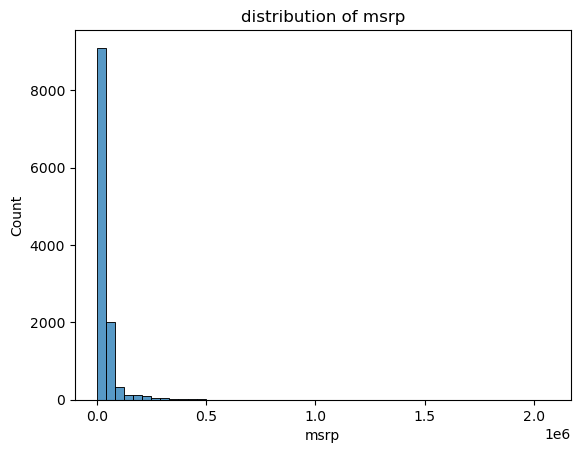

In [71]:
sns.histplot(df.msrp, bins=50)
plt.title("distribution of msrp")
plt.show()

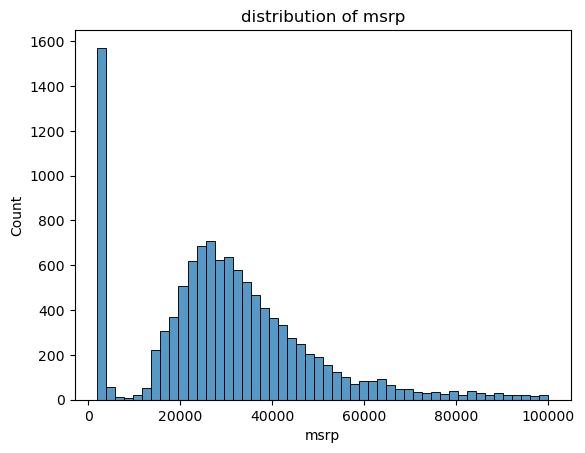

In [72]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)
plt.title("distribution of msrp")
plt.show()

- MSRP → right-skewed distribution with a long tail → apply log transformation for now.

In [73]:
price_logs = np.log1p(df['msrp'])

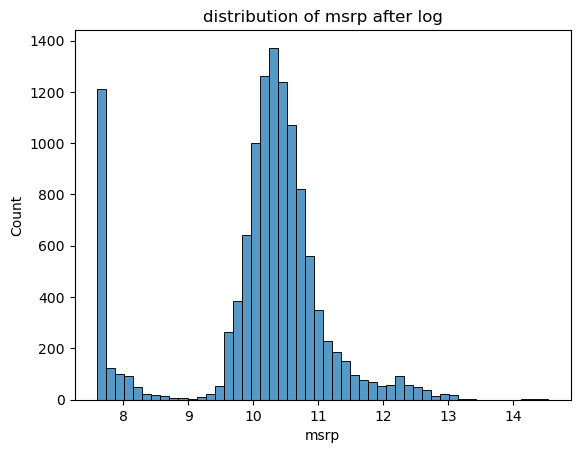

In [74]:
sns.histplot(price_logs, bins=50)
plt.title("distribution of msrp after log")
plt.show()

**Missing values**

In [75]:
df.isna().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

#### 1.3 Setting Up the Validation Framework

In [76]:
# Split the data
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# Shuffle the data
np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

# Split the data
df_train = df.iloc[idx[:n_train]]
df_test = df.iloc[idx[n_train:n_train + n_test]]
df_val = df.iloc[idx[n_train + n_test:]]

In [77]:
# Reset indices
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

In [78]:
df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,gmc,vandura,1994,regular_unleaded,165.0,6.0,automatic,rear_wheel_drive,3.0,NaN,compact,cargo_van,20,15,549,2000
1,mercedes-benz,600-class,1993,regular_unleaded,389.0,12.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,15,11,617,3211
2,toyota,venza,2013,regular_unleaded,268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",midsize,wagon,25,18,2031,31120
3,volvo,740,1992,regular_unleaded,114.0,4.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,26,18,870,2000
4,ford,crown_victoria,2010,flex-fuel_(unleaded/e85),224.0,8.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,sedan,24,16,5657,29905


In [79]:
df_train.shape , df_test.shape, df_val.shape

((7150, 16), (2382, 16), (2382, 16))

In [80]:
# target
y_train = np.log1p(df_train.msrp.values)
y_test = np.log1p(df_test.msrp.values)
y_val = np.log1p(df_val.msrp.values)

In [81]:
# Delete the target from features
del df_train["msrp"]
del df_test["msrp"]
del df_val["msrp"]

#### 1.4 Linear regression

In [82]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [83]:
xi =[453, 11, 86]
w0 = 7.17
w = [0.01,0.04,0.002]

In [88]:
def linear_regression(xi):
    m = len(xi)
    pred = w0
    for i in range(m):
        pred +=  w[i]*xi[i]
    return pred
linear_regression(xi)

12.312

In [86]:
np.expm1(12.312)

np.float64(222347.2221101062)